## Import Statements

In [1]:
import torch
import torch_geometric
from torch_geometric import utils
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from scipy.sparse import coo_matrix
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from torch_geometric.explain.algorithm import GNNExplainer
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score

## Load in Hi-C Matrices and node information, build graph

In [2]:
ec_hic = np.load('data/ec_adj_mat_t25.npy')
hsr_hic = np.load('data/hsr_adj_mat_t25.npy')

ec_df = pd.read_csv('data/ec_cleaned.csv')
hsr_df = pd.read_csv('data/hsr_cleaned.csv')

hsr_feats = torch.tensor(hsr_df[['read_count', 'total_genes']].to_numpy())
hsr_labels = torch.zeros(hsr_feats.shape[0])

ec_feats = torch.tensor(ec_df[['read_count', 'total_genes']].to_numpy())
ec_labels = torch.ones(ec_feats.shape[0])

def hic_to_sparse(hic_mat):
    adj_mat = np.triu(hic_mat)
    sparse_adj = coo_matrix(adj_mat)

    return utils.from_scipy_sparse_matrix(sparse_adj)

hsr_edge_index, hsr_edge_attr = hic_to_sparse(hsr_hic)
hsr_graph = torch_geometric.data.Data(edge_index = hsr_edge_index, edge_attr = hsr_edge_attr, x = hsr_feats, y = hsr_labels)

ec_edge_index, ec_edge_attr = hic_to_sparse(ec_hic)
ec_graph = torch_geometric.data.Data(edge_index = ec_edge_index, edge_attr = ec_edge_attr, x = ec_feats, y = ec_labels)

x = torch.cat([ec_feats, hsr_feats], dim=0)
hsr_edge_index = hsr_edge_index + ec_labels.shape[0]
edge_index = torch.cat([ec_edge_index, hsr_edge_index], dim=1)
edge_attr = torch.cat([ec_edge_attr, hsr_edge_attr], dim=0)
labels = torch.cat([ec_labels, hsr_labels], dim=0)

G = torch_geometric.data.Data(edge_index = edge_index, edge_attr = edge_attr, x = x, y = labels)

In [3]:
G.x

tensor([[  7,   0],
        [  4,   0],
        [ 20,   0],
        ...,
        [157,   0],
        [208,   0],
        [136,   0]])

In [4]:
G.y

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 

## Build GraphSAGE

In [5]:
# Model inputs + layer information
num_features = G.num_node_features
num_classes = 2
graph_sage_layer_sizes = [8,16]
linear_layer_sizes = [16,8]

In [6]:
# Define GraphSAGE
class GraphSAGE(nn.Module):
    def __init__(self, num_feat, graph_conv_layer_sizes, lin_hidden_sizes, num_classes):
        super().__init__()
        self.embeddings = None
        self.conv1 = SAGEConv(num_feat, graph_conv_layer_sizes[0])
        self.conv2 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])

        self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
        self.lin2 = nn.Linear(lin_hidden_sizes[1], num_classes)
            
        self.loss_calc = nn.CrossEntropyLoss()
        self.torch_softmax = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        x = x.float()  # Ensure x is in float format
    
        ### Graph convolution module
        h = self.conv1(x, edge_index)
        h = torch.relu(h)
        h = self.conv2(h, edge_index)
        h = torch.relu(h)
            
        self.embeddings = h
        scores = h
        
        scores = self.lin1(scores)
        scores = torch.relu(scores)
        scores = self.lin2(scores)
        
        return scores


    def loss(self, scores, labels):
        xent_loss = self.loss_calc(scores, labels)
        return xent_loss
    
    def calc_softmax_pred(self, scores):
        softmax = self.torch_softmax(scores)
        predicted = torch.argmax(softmax, 1)
        return softmax, predicted

    def get_embeddings(self):
        if self.embeddings is not None:
            return self.embeddings

        print("Untrained Model: Please train model first")
        return None

## Read in model

In [7]:
model = GraphSAGE(num_features, graph_sage_layer_sizes, linear_layer_sizes, num_classes)
path = 'model/graphsage_statedict.pth'
model.load_state_dict(torch.load(path))

<All keys matched successfully>

In [8]:
model

GraphSAGE(
  (conv1): SAGEConv(2, 8, aggr=mean)
  (conv2): SAGEConv(8, 16, aggr=mean)
  (lin1): Linear(in_features=16, out_features=8, bias=True)
  (lin2): Linear(in_features=8, out_features=2, bias=True)
  (loss_calc): CrossEntropyLoss()
  (torch_softmax): Softmax(dim=1)
)

## GNN Explainer

In [9]:
# Define the model configuration
model_config = ModelConfig(
    mode="binary_classification",  # Change this based on your task type
    task_level="node",  # Explaining node-level predictions
    return_type="raw",  # Adjust based on what your model returns
)

# Initialize the explainer with the required configuration
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type='model',
    node_mask_type='attributes',  # Explains node features
    edge_mask_type='object',  # Explains edge importance
    model_config=model_config,  # Required argument
)

# Explain a specific node
node_idx = 7
explanation = explainer(x=G.x, edge_index=G.edge_index) 

# Extract feature and edge masks
node_feat_mask = explanation.node_mask
edge_mask = explanation.edge_mask

print("Size of explanation:", sum(edge_mask > 0))

Size of explanation: tensor(15813)


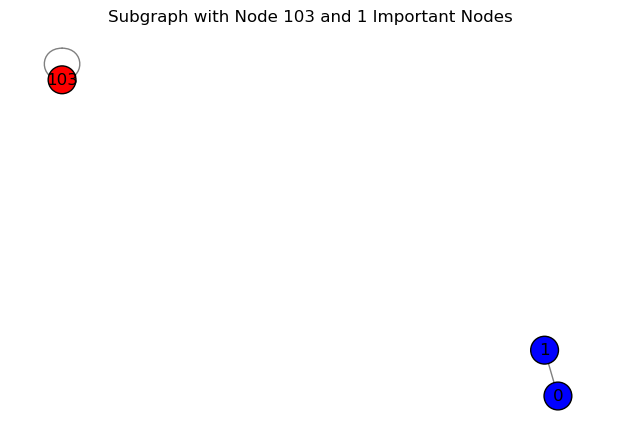

In [22]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.utils import to_networkx

def visualize_selected_nodes(data, explanation, selected_node=7, top_k=5):
    """
    Visualizes a subgraph containing only the selected node and the k most important nodes.
    
    Parameters:
    - data: PyG data object (original graph)
    - explanation: PyG explanation object containing node_mask
    - selected_node: The main node to always include (e.g., node 7)
    - top_k: Number of most important nodes to highlight
    """
    # Convert PyG graph to NetworkX format
    G = to_networkx(data, to_undirected=True)

    # Extract node importance scores
    node_mask = explanation.node_mask.squeeze()  # Shape: [num_nodes]

    # Get top-k most important nodes (excluding the selected node if it's already in the top-k)
    top_nodes = torch.topk(node_mask, top_k).indices.squeeze().tolist()
    if selected_node not in top_nodes:
        top_nodes.append(selected_node)  # Ensure the selected node is included

    # Create a subgraph with only the selected nodes
    subgraph = G.subgraph(top_nodes)

    # Assign colors (red for the selected node, blue for important nodes)
    node_colors = ['red' if node == selected_node else 'blue' for node in subgraph.nodes]

    # Draw the subgraph
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(subgraph)  # Layout for visualization
    nx.draw(subgraph, pos, with_labels=True, node_size=400, node_color=node_colors, edge_color='gray', edgecolors='black')

    plt.title(f"Subgraph with Node {selected_node} and {top_k} Important Nodes")
    plt.show()

# Example Usage:
# Assuming `data` is the PyG Data object and `explanation` is the explanation result
visualize_selected_nodes(G, explanation, selected_node=103, top_k=1)
